In [1]:
!pip install opencv-python matplotlib

In [3]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

print("OpenCV version:", cv2.__version__)
print("Libraries loaded successfully!")

OpenCV version: 5.0.0
Libraries loaded successfully!


In [4]:
# Download MobileNet-SSD model files

!wget -q https://raw.githubusercontent.com/chuanqi305/MobileNet-SSD/master/deploy.prototxt
!wget -q https://github.com/chuanqi305/MobileNet-SSD/raw/master/mobilenet_iter_73000.caffemodel

print("MobileNet-SSD model downloaded successfully!")

MobileNet-SSD model downloaded successfully!


In [5]:
import os

print("deploy.prototxt:", os.path.exists("deploy.prototxt"))
print("caffemodel:", os.path.exists("mobilenet_iter_73000.caffemodel"))

deploy.prototxt: True
caffemodel: True


In [7]:
import cv2

print(cv2.__version__)
print(hasattr(cv2.dnn, "readNetFromCaffe"))

5.0.0
False


In [8]:
!pip uninstall -y opencv-python opencv-contrib-python opencv-python-headless
!pip install opencv-python==4.10.0.84

Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93
Found existing installation: opencv-contrib-python 4.14.0.94
Uninstalling opencv-contrib-python-4.14.0.94:
  Successfully uninstalled opencv-contrib-python-4.14.0.94
Found existing installation: opencv-python-headless 5.0.0.93
Uninstalling opencv-python-headless-5.0.0.93:
  Successfully uninstalled opencv-python-headless-5.0.0.93
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 16.7 MB/s eta 0:00:00


In [1]:
import cv2

print("OpenCV version:", cv2.__version__)
print("Caffe support:", hasattr(cv2.dnn, "readNetFromCaffe"))

OpenCV version: 4.10.0
Caffe support: True


In [2]:
prototxt_path = "deploy.prototxt"
model_path = "mobilenet_iter_73000.caffemodel"

net = cv2.dnn.readNetFromCaffe(
    prototxt_path,
    model_path
)

print("MobileNet-SSD model loaded successfully!")

MobileNet-SSD model loaded successfully!


In [4]:
from google.colab import files

uploaded = files.upload()

image_path = next(iter(uploaded))
print("Image uploaded:", image_path)

Saving 533f3b29-8b24-4520-9efe-f49977cf6be0.png to 533f3b29-8b24-4520-9efe-f49977cf6be0.png
Image uploaded: 533f3b29-8b24-4520-9efe-f49977cf6be0.png


In [5]:
image = cv2.imread(image_path)

if image is None:
    print("Error: Could not read the image.")
else:
    print("Image loaded successfully!")
    print("Image shape:", image.shape)

Image loaded successfully!
Image shape: (1024, 1536, 3)


In [6]:
blob = cv2.dnn.blobFromImage(
    cv2.resize(image, (300, 300)),
    0.007843,
    (300, 300),
    127.5
)

print("Blob created successfully!")
print("Blob shape:", blob.shape)

Blob created successfully!
Blob shape: (1, 3, 300, 300)


In [7]:
net.setInput(blob)

detections = net.forward()

print("Object detection completed!")
print("Number of detections:", detections.shape[2])

Object detection completed!
Number of detections: 100


In [25]:
CLASSES = [
    "background", "aeroplane", "bicycle", "bird", "boat",
    "bottle", "bus", "car", "cat", "chair", "cow", "diningtable",
    "dog", "horse", "motorbike", "person", "pottedplant",
    "sheep", "sofa", "train", "tvmonitor"
]

CONFIDENCE_THRESHOLD = 0.50
detected_objects = []

for i in range(detections.shape[2]):
    confidence = detections[0, 0, i, 2]

    if confidence >= CONFIDENCE_THRESHOLD:
        class_id = int(detections[0, 0, i, 1])
        label = CLASSES[class_id]

        detected_objects.append((label, confidence))

print("Objects detected with confidence >= 50%:")
for label, confidence in detected_objects:
    print(f"{label}: {confidence * 100:.2f}%")

Objects detected with confidence >= 50%:
person: 98.84%
car: 97.75%
car: 95.93%
person: 82.71%
dog: 59.80%


In [26]:
output_image = image.copy()

h, w = image.shape[:2]

for i in range(detections.shape[2]):
    confidence = detections[0, 0, i, 2]

    if confidence >= CONFIDENCE_THRESHOLD:
        class_id = int(detections[0, 0, i, 1])
        label = CLASSES[class_id]

        box = detections[0, 0, i, 3:7] * [w, h, w, h]
        startX, startY, endX, endY = box.astype("int")

        cv2.rectangle(
            output_image,
            (startX, startY),
            (endX, endY),
            (0, 255, 0),
            2
        )

        text = f"{label}: {confidence * 100:.1f}%"

        cv2.putText(
            output_image,
            text,
            (startX, max(startY - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

print("Bounding boxes added successfully!")

Bounding boxes added successfully!


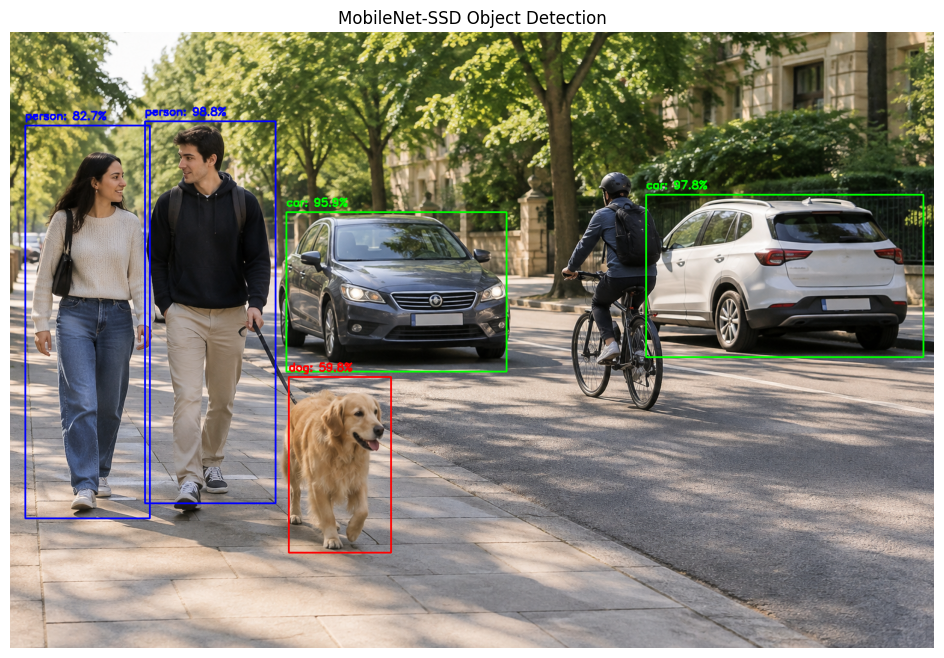

In [27]:
VISUALIZATION_THRESHOLD = 0.50

visual_image = image.copy()

h, w = image.shape[:2]

# Different color for each object class
CLASS_COLORS = {
    "person": (255, 0, 0),       # Blue
    "car": (0, 255, 0),          # Green
    "dog": (0, 0, 255),          # Red
    "bicycle": (255, 255, 0),    # Cyan
    "bottle": (255, 0, 255),     # Magenta
    "chair": (0, 255, 255),      # Yellow
    "bus": (128, 0, 128),         # Purple
    "motorbike": (0, 165, 255),  # Orange
    "cat": (128, 128, 0),        # Teal
    "bird": (255, 128, 0)        # Light blue
}

# Default color for any other class
DEFAULT_COLOR = (255, 255, 255)

for i in range(detections.shape[2]):

    confidence = detections[0, 0, i, 2]

    if confidence >= VISUALIZATION_THRESHOLD:

        class_id = int(detections[0, 0, i, 1])
        label = CLASSES[class_id]

        box = detections[0, 0, i, 3:7] * [w, h, w, h]
        startX, startY, endX, endY = box.astype("int")

        # Select color according to object class
        color = CLASS_COLORS.get(label, DEFAULT_COLOR)

        # Draw bounding box
        cv2.rectangle(
            visual_image,
            (startX, startY),
            (endX, endY),
            color,
            2
        )

        # Label with confidence
        text = f"{label}: {confidence * 100:.1f}%"

        cv2.putText(
            visual_image,
            text,
            (startX, max(startY - 10, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2
        )

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(visual_image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("MobileNet-SSD Object Detection")
plt.show()

In [29]:
from collections import Counter

# Store objects detected at 50% or higher
detected_objects_50 = []

for i in range(detections.shape[2]):
    confidence = detections[0, 0, i, 2]

    if confidence >= 0.50:
        class_id = int(detections[0, 0, i, 1])
        label = CLASSES[class_id]

        detected_objects_50.append(label)

# Count detected objects
object_counts = Counter(detected_objects_50)

print("===== OBJECT DETECTION SUMMARY =====")
print("Confidence Threshold: 50%")
print()

if object_counts:
    for label, count in object_counts.items():
        print(f"{label}: {count}")

    print(f"\nTotal objects detected: {sum(object_counts.values())}")
else:
    print("No objects detected.")

===== OBJECT DETECTION SUMMARY =====
Confidence Threshold: 50%

person: 2
car: 2
dog: 1

Total objects detected: 5


In [30]:
# Confidence benchmarking

confidence_scores = []

for i in range(detections.shape[2]):
    confidence = detections[0, 0, i, 2]

    if confidence >= 0.50:
        confidence_scores.append(confidence)

print("===== CONFIDENCE BENCHMARK =====")
print("Confidence Threshold: 50%")

if confidence_scores:
    print(f"Total detections: {len(confidence_scores)}")
    print(f"Highest confidence: {max(confidence_scores) * 100:.2f}%")
    print(f"Lowest confidence: {min(confidence_scores) * 100:.2f}%")
    print(f"Average confidence: {(sum(confidence_scores) / len(confidence_scores)) * 100:.2f}%")
else:
    print("No detections found.")

===== CONFIDENCE BENCHMARK =====
Confidence Threshold: 50%
Total detections: 5
Highest confidence: 98.84%
Lowest confidence: 59.80%
Average confidence: 87.01%


In [31]:
output_path = "mobilenet_ssd_detection_result.jpg"

cv2.imwrite(output_path, visual_image)

print("Final detection image saved successfully!")
print("File:", output_path)

Final detection image saved successfully!
File: mobilenet_ssd_detection_result.jpg


In [33]:
from google.colab import files

files.download("mobilenet_ssd_detection_result.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>